In [ ]:
# ==============================
# STEP 1: UPLOAD ZIP FILE
# ==============================
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
# ==============================
# STEP 2: UNZIP DATASET
# ==============================
import zipfile
import os

zip_path = list(uploaded.keys())[0]   # uploaded zip file name
extract_path = "/content/dataset_raw"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset_raw


In [ ]:
# ==============================
# STEP 3: FIND MAIN DATASET FOLDER
# ==============================
# Sometimes zip creates an extra folder inside.
# This helps locate the actual class folders.

def find_dataset_root(path):
    while True:
        items = [os.path.join(path, x) for x in os.listdir(path)]
        dirs = [x for x in items if os.path.isdir(x)]

        # Stop if current folder directly contains class folders
        if len(dirs) > 0 and all(
            any(fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
                for fname in os.listdir(d)) for d in dirs
        ):
            return path

        # If only one folder inside, go deeper
        if len(dirs) == 1:
            path = dirs[0]
        else:
            return path

dataset_root = find_dataset_root(extract_path)
print("Dataset root found at:", dataset_root)
print("Classes:", os.listdir(dataset_root))

Dataset root found at: /content/dataset_raw/dataset
Classes: ['Bacterial_wilt', 'Healthy', 'Early_Blight', 'Late_Blight']


In [ ]:
# ==============================
# STEP 4: REMOVE DUPLICATES
# ==============================
import hashlib
import shutil

clean_path = "/content/dataset_clean"
os.makedirs(clean_path, exist_ok=True)

image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

for class_name in os.listdir(dataset_root):
    class_path = os.path.join(dataset_root, class_name)
    if not os.path.isdir(class_path):
        continue

    save_class_path = os.path.join(clean_path, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    seen_hashes = set()
    duplicate_count = 0
    kept_count = 0

    for fname in os.listdir(class_path):
        if not fname.lower().endswith(image_exts):
            continue

        src = os.path.join(class_path, fname)
        try:
            img_hash = file_hash(src)
            if img_hash not in seen_hashes:
                seen_hashes.add(img_hash)
                shutil.copy2(src, os.path.join(save_class_path, fname))
                kept_count += 1
            else:
                duplicate_count += 1
        except Exception as e:
            print(f"Skipping {src}: {e}")

    print(f"{class_name}: kept {kept_count}, removed duplicates {duplicate_count}")

print("Duplicate removal done.")

Bacterial_wilt: kept 569, removed duplicates 0
Healthy: kept 813, removed duplicates 3
Early_Blight: kept 1303, removed duplicates 0
Late_Blight: kept 1132, removed duplicates 0
Duplicate removal done.


In [ ]:
# ==============================
# STEP 5: MAKE ALL CLASSES EQUAL
# ==============================
import random

balanced_path = "/content/dataset_balanced"
os.makedirs(balanced_path, exist_ok=True)

class_counts = {}
for class_name in os.listdir(clean_path):
    class_path = os.path.join(clean_path, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
    class_counts[class_name] = len(images)

print("Class counts after duplicate removal:", class_counts)

min_count = min(class_counts.values())
print("Using", min_count, "images per class")

random.seed(42)

for class_name in os.listdir(clean_path):
    class_path = os.path.join(clean_path, class_name)
    if not os.path.isdir(class_path):
        continue

    save_class_path = os.path.join(balanced_path, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    images = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
    selected_images = random.sample(images, min_count)

    for fname in selected_images:
        shutil.copy2(
            os.path.join(class_path, fname),
            os.path.join(save_class_path, fname)
        )

print("Balancing done.")

Class counts after duplicate removal: {'Bacterial_wilt': 569, 'Healthy': 813, 'Early_Blight': 1303, 'Late_Blight': 1132}
Using 569 images per class
Balancing done.


In [ ]:
# ==============================
# STEP 6: SPLIT INTO 70-20-10
# ==============================
split_base = "/content/final_dataset"
train_path = os.path.join(split_base, "train")
val_path   = os.path.join(split_base, "val")
test_path  = os.path.join(split_base, "test")

for p in [train_path, val_path, test_path]:
    os.makedirs(p, exist_ok=True)

for class_name in os.listdir(balanced_path):
    class_path = os.path.join(balanced_path, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(image_exts)]
    random.shuffle(images)

    total = len(images)
    train_end = int(total * 0.70)
    val_end = train_end + int(total * 0.20)

    train_imgs = images[:train_end]
    val_imgs   = images[train_end:val_end]
    test_imgs  = images[val_end:]

    for split_name, split_imgs in zip(
        ["train", "val", "test"],
        [train_imgs, val_imgs, test_imgs]
    ):
        split_class_path = os.path.join(split_base, split_name, class_name)
        os.makedirs(split_class_path, exist_ok=True)

        for fname in split_imgs:
            shutil.copy2(
                os.path.join(class_path, fname),
                os.path.join(split_class_path, fname)
            )

    print(f"{class_name}: train={len(train_imgs)}, val={len(val_imgs)}, test={len(test_imgs)}")

print("Dataset split complete.")

Bacterial_wilt: train=398, val=113, test=58
Healthy: train=398, val=113, test=58
Early_Blight: train=398, val=113, test=58
Late_Blight: train=398, val=113, test=58
Dataset split complete.


In [ ]:
# ==============================
# STEP 7: CHECK FINAL COUNTS
# ==============================
for split_name in ["train", "val", "test"]:
    print(f"\n{split_name.upper()}:")
    split_path = os.path.join(split_base, split_name)
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(image_exts)])
        print(f"  {class_name}: {count}")


TRAIN:
  Bacterial_wilt: 398
  Healthy: 398
  Early_Blight: 398
  Late_Blight: 398

VAL:
  Bacterial_wilt: 113
  Healthy: 113
  Early_Blight: 113
  Late_Blight: 113

TEST:
  Bacterial_wilt: 58
  Healthy: 58
  Early_Blight: 58
  Late_Blight: 58


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
train_dir = '/content/final_dataset/train'
test_dir ='/content/final_dataset/test'

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42)

val_data = train_gen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42)

test_data = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir, target_size=(224,224), batch_size=32,
    class_mode='categorical', shuffle=False)


Found 1276 images belonging to 4 classes.
Found 316 images belonging to 4 classes.
Found 232 images belonging to 4 classes.


In [ ]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,065,572 (84.17 MB)

 Trainable params: 262,788 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
import os
from PIL import Image

train_dir = '/content/final_dataset/train'
test_dir  = '/content/final_dataset/test'

def check_images(path):
    bad_files = []
    for root, _, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            try:
                with Image.open(fp) as img:
                    img.verify()
            except Exception:
                bad_files.append(fp)
    return bad_files

bad_train = check_images(train_dir)
bad_test = check_images(test_dir)
print("Bad images in train:", len(bad_train))
print("Bad images in test:", len(bad_test))

# Optional: list them
for b in bad_train[:10]:
    print("❌", b)


Bad images in train: 0
Bad images in test: 0


In [ ]:
for b in bad_train + bad_test:
    os.remove(b)
print("✅ Corrupted images removed")


✅ Corrupted images removed


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='training', seed=42)

val_data = train_gen.flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32,
    class_mode='categorical', subset='validation', seed=42)


Found 1276 images belonging to 4 classes.
Found 316 images belonging to 4 classes.


In [ ]:
history = model.fit(train_data, validation_data=val_data, epochs=10)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5063 - loss: 1.1183 - val_accuracy: 0.6994 - val_loss: 0.8159
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7406 - loss: 0.6632 - val_accuracy: 0.7753 - val_loss: 0.6098
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 761ms/step - accuracy: 0.7908 - loss: 0.5403 - val_accuracy: 0.7753 - val_loss: 0.5286
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 754ms/step - accuracy: 0.8182 - loss: 0.4613 - val_accuracy: 0.7785 - val_loss: 0.5185
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 802ms/step - accuracy: 0.8527 - loss: 0.4151 - val_accuracy: 0.8070 - val_loss: 0.4921
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 772ms/step - accuracy: 0.8660 - loss: 0.3816 - val_accuracy: 0.7658 - val_loss: 0.5127
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 30s 752ms/step - accuracy: 0.8487 - loss: 0.3829 - val_accuracy: 0.7911 - val_loss: 0.4735
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 31s 791ms/step - accuracy: 0.8801 - loss: 0.3327 - val_accuracy: 

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8879 - loss: 0.3080
✅ Test Accuracy: 88.79%


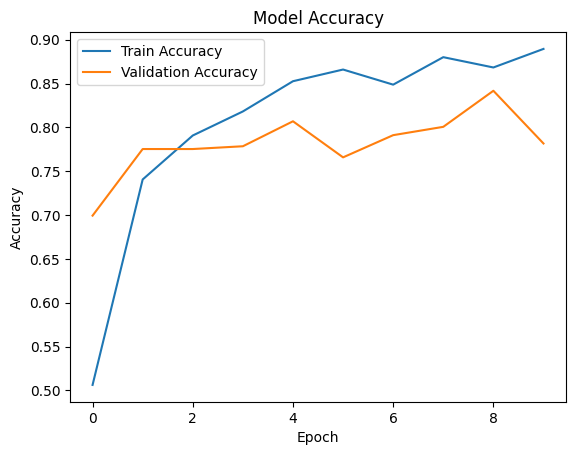

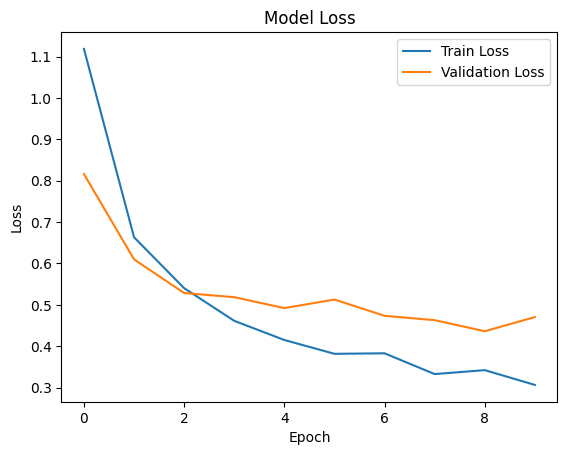

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.show()


In [ ]:
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_data.classes, y_pred, target_names=list(test_data.class_indices.keys())))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
                precision    recall  f1-score   support

Bacterial_wilt       1.00      1.00      1.00        58
  Early_Blight       0.91      0.91      0.91        58
       Healthy       0.85      0.78      0.81        58
   Late_Blight       0.79      0.86      0.83        58

      accuracy                           0.89       232
     macro avg       0.89      0.89      0.89       232
  weighted avg       0.89      0.89      0.89       232



In [ ]:
model.save('/content/drive/MyDrive/maize_inception_v3_balanced.h5')
print("✅ Model saved to Drive!")


✅ Model saved to Drive!


In [ ]:
import cv2

model = tf.keras.models.load_model('/content/drive/MyDrive/maize_inception_v3_balanced.h5')
class_labels = list(test_data.class_indices.keys())

cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    img = cv2.resize(frame, (224,224))
    img = np.expand_dims(img/255.0, axis=0)
    preds = model.predict(img)
    label = class_labels[np.argmax(preds)]
    conf = np.max(preds)
    cv2.putText(frame, f'{label} ({conf:.2f})', (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    cv2.imshow('Maize Disease Detection', frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release(); cv2.destroyAllWindows()
